In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rioxarray as rxa
import xarray as xr

from pyinterpolate import reproject_flat, build_experimental_variogram

In [2]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/'

pref = 'uavsar_geoslcs_cropped/stlake/27129/'
fnames = ['stlake_27129_21022_001_210322_L090VV_01_BC_s1_1x1.slc.complex_cropped.tif',
          'stlake_27129_21020_024_210316_L090VV_01_BC_s1_1x1.slc.complex_cropped.tif',
          'stlake_27129_21018_002_210310_L090VV_01_BC_s1_1x1.slc.complex_cropped.tif',
          'stlake_27129_21016_001_210303_L090VV_01_BC_s1_1x1.slc.complex_cropped.tif',
          'stlake_27129_21011_012_210210_L090VV_01_BC_s1_1x1.slc.complex_cropped.tif',
          'stlake_27129_21010_001_210203_L090VV_01_BC_s1_1x1.slc.complex_cropped.tif']
dates = [f.split('_')[4] for f in fnames]

In [3]:
files = [rxa.open_rasterio(data_dir + pref + f).squeeze() for f in fnames]

In [4]:
files_xr = xr.concat(files, dim=dates)
files_xr = (
    files_xr.rename(concat_dim='date')
    .rio.write_crs('EPSG:4326')
    .drop('band')
)
files_xr

/tmp/ipykernel_82227/2813046149.py:5: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  .drop('band')


<xarray.DataArray (date: 6, y: 2957, x: 6205)> Size: 881MB
array([[[ 1.85996190e-01-9.35481563e-02j,
          6.53897047e-01-4.99664946e-03j,
          6.05404913e-01+2.62966193e-02j, ...,
          8.76670629e-02+1.47495762e-01j,
          7.14028254e-02+2.67655313e-01j,
          4.68351170e-02+2.68509150e-01j],
        [ 1.85996190e-01-9.35481563e-02j,
          6.53897047e-01-4.99664946e-03j,
          6.05404913e-01+2.62966193e-02j, ...,
          8.76670629e-02+1.47495762e-01j,
          7.14028254e-02+2.67655313e-01j,
          4.68351170e-02+2.68509150e-01j],
        [ 1.85996190e-01-9.35481563e-02j,
          6.53897047e-01-4.99664946e-03j,
          6.05404913e-01+2.62966193e-02j, ...,
          8.76670629e-02+1.47495762e-01j,
          7.14028254e-02+2.67655313e-01j,
          4.68351170e-02+2.68509150e-01j],
        ...,
        [-4.79481881e-03+2.31425855e-02j,
...
        ...,
        [-3.23168677e-03-1.73662715e-02j,
         -3.23168677e-03-1.73662715e-02j,
         -4.31454778e-02+9.43809934e-03j, ...,
          1.71437878e-02+7.05391634e-03j,
          1.27753671e-02-4.42345673e-03j,
         -1.65903461e-04-2.75871716e-02j],
        [-3.23168677e-03-1.73662715e-02j,
         -3.80371301e-03+4.05358709e-03j,
         -4.31454778e-02+9.43809934e-03j, ...,
         -1.85488798e-02+1.01311626e-02j,
         -1.18646456e-03-5.52270235e-03j,
          7.38201290e-03-2.25786008e-02j],
        [ 5.27855381e-03+1.78974234e-02j,
         -1.01693114e-03+1.15363253e-02j,
         -2.84344330e-02-4.82310168e-03j, ...,
         -4.83819135e-02+9.06971563e-03j,
         -2.78745405e-02-2.14733575e-02j,
         -3.82779422e-03-3.57445925e-02j]]],
      shape=(6, 2957, 6205), dtype=complex64)
Coordinates:
  * date         (date) object 48B '210322' '210316' ... '210210' '210203'
  * y            (y) float64 24kB 40.61 40.61 40.61 40.61 ... 40.59 40.59 40.59
  * x            (x) float64 50kB -111.7 -111.7 -111.7 ... -111.7 -111.7 -111.7
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:    (-9999+0j)
    scale_factor:  1.0
    add_offset:    0.0

In [5]:
phase_da = xr.apply_ufunc(np.angle, files_xr)

data = xr.Dataset(
    data_vars={
        "amplitude": np.abs(files_xr),
        "phase": phase_da,
    }
)

if "_FillValue" in data["amplitude"].attrs:
    del data["amplitude"].attrs["_FillValue"]
if "_FillValue" in data["phase"].attrs:
    del data["phase"].attrs["_FillValue"]
if "_FillValue" in data.attrs:
    del data.attrs["_FillValue"]
    
data = data.rio.reproject(dst_crs='EPSG:32612')
data

<xarray.Dataset> Size: 1GB
Dimensions:      (x: 5858, y: 3690, date: 6)
Coordinates:
  * x            (x) float64 47kB 4.38e+05 4.38e+05 ... 4.42e+05 4.42e+05
  * y            (y) float64 30kB 4.496e+06 4.496e+06 ... 4.493e+06 4.493e+06
  * date         (date) object 48B '210322' '210316' ... '210210' '210203'
    spatial_ref  int64 8B 0
Data variables:
    amplitude    (date, y, x) float32 519MB nan nan nan nan ... nan nan nan nan
    phase        (date, y, x) float32 519MB nan nan nan nan ... nan nan nan nan

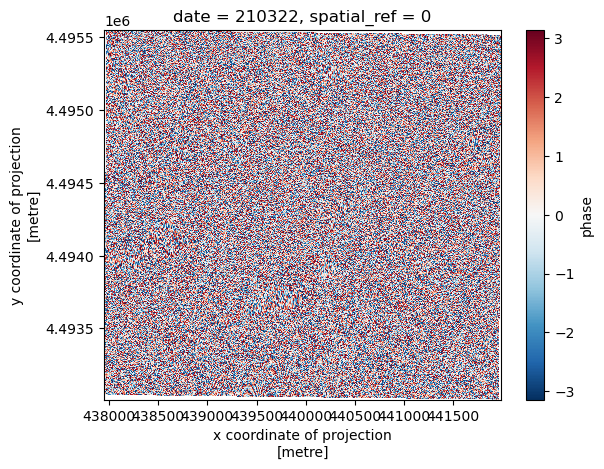

In [6]:
data['phase'].sel(date='210322').plot()

In [7]:
pref = 'uavsar_cohs_cropped/stlake/27129/'
fnames = ['stlake_27129_210316_210322_VV_s1_w3x12_int_coh.tif',
          'stlake_27129_210322_HV-VH_s1_w3x12_crosspol_coh.tif']
idx = np.arange(len(fnames))

In [8]:
files = [rxa.open_rasterio(data_dir + pref + f).squeeze() for f in fnames]
files_xr = xr.concat(files, dim=idx)
files_xr = (
    files_xr.rename(concat_dim='date')
    .rio.write_crs('EPSG:4326')
    .rio.reproject(dst_crs='EPSG:32612')
    .drop('band')
)
files_xr

/tmp/ipykernel_82227/4105418113.py:7: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  .drop('band')


<xarray.DataArray (date: 2, y: 3690, x: 5858)> Size: 173MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(2, 3690, 5858), dtype=float32)
Coordinates:
  * date         (date) int64 16B 0 1
  * y            (y) float64 30kB 4.496e+06 4.496e+06 ... 4.493e+06 4.493e+06
  * x            (x) float64 47kB 4.38e+05 4.38e+05 ... 4.42e+05 4.42e+05
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0
    _FillValue:    nan

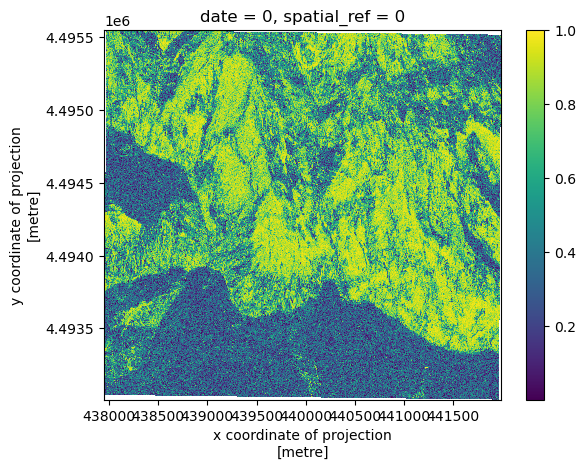

In [9]:
files_xr.sel(date=0).plot()

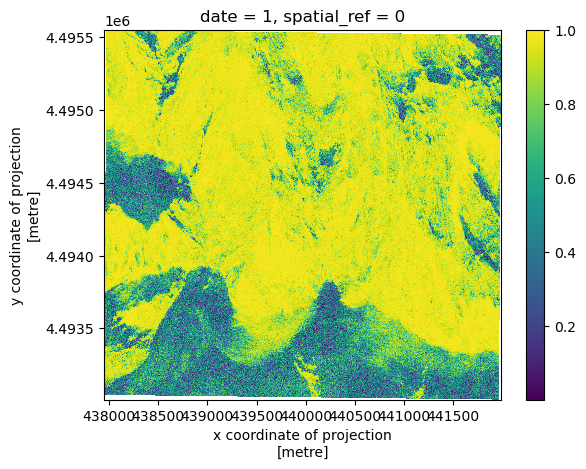

In [10]:
files_xr.sel(date=1).plot()

In [11]:
phase_slice = data['phase'].sel(date='210322')
pixel_size = abs(phase_slice.rio.transform()[0])
print(f"Detected pixel resolution: {pixel_size} meters")

Detected pixel resolution: 0.6886885969506745 meters


Building variogram for 210322 coherence between 0 and 0.2 (mean: 0.1341545283794403)...


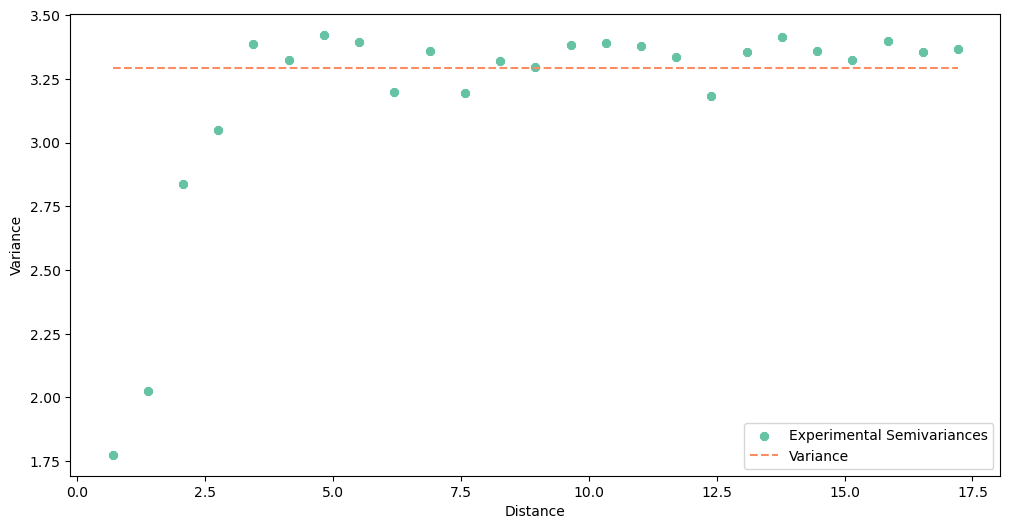

Building variogram for 210322 coherence between 0.2 and 0.4 (mean: 0.3122501075267792)...


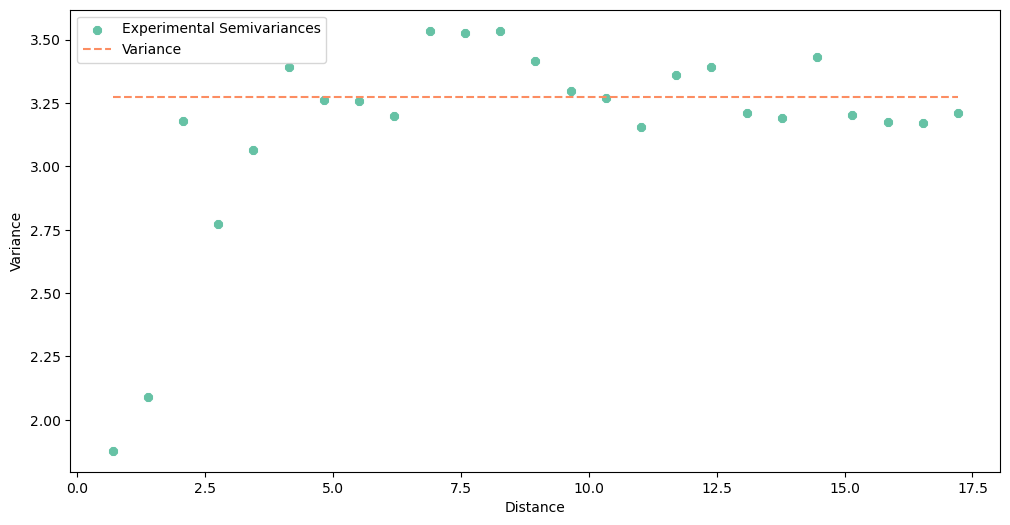

Building variogram for 210322 coherence between 0.4 and 0.6 (mean: 0.5035066604614258)...


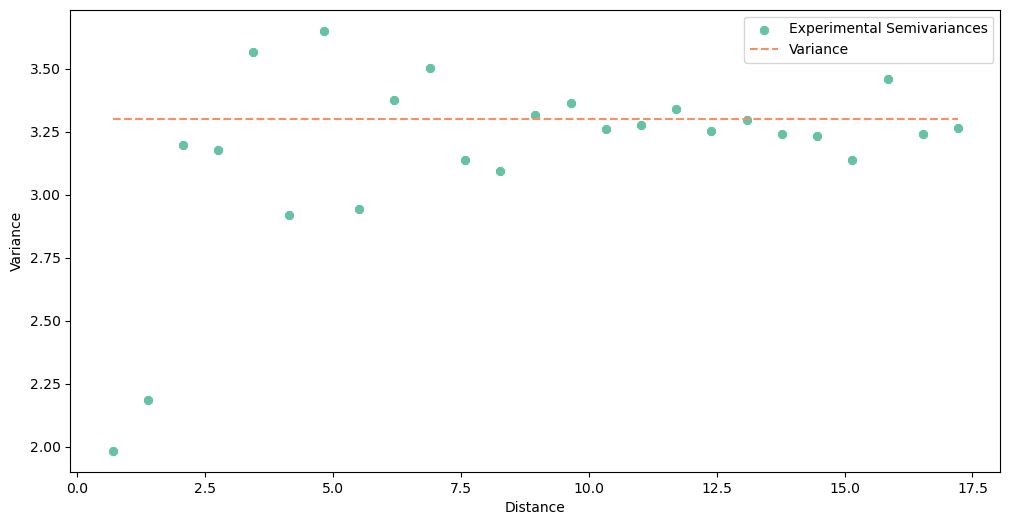

Building variogram for 210322 coherence between 0.6 and 0.8 (mean: 0.7033483982086182)...


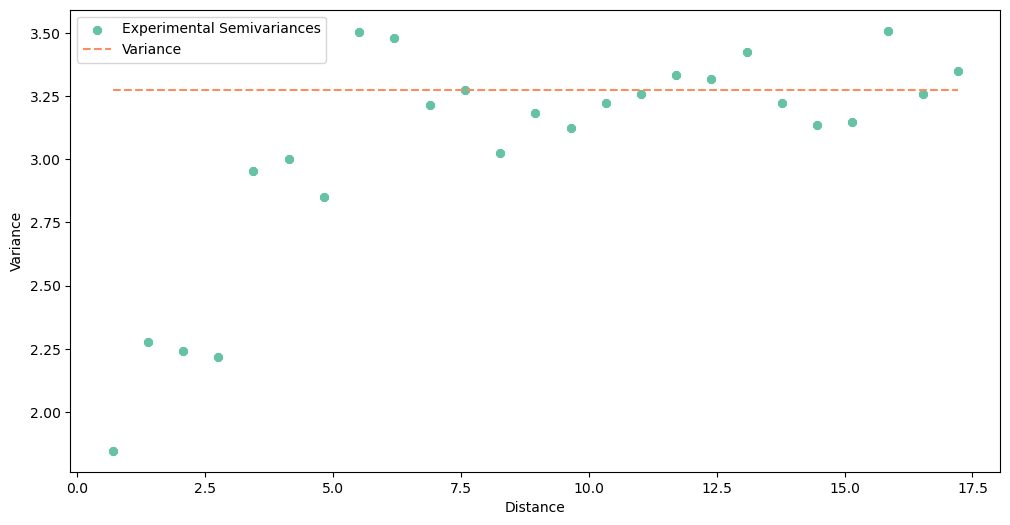

Building variogram for 210322 coherence between 0.8 and 1 (mean: 0.9432182908058167)...


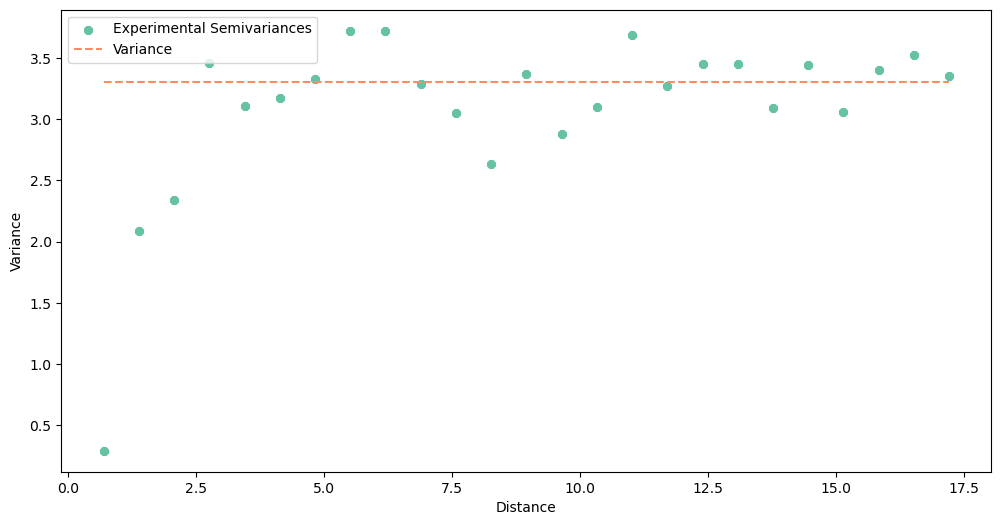

In [14]:
d = '210322'

cutoffs = [0, 0.2, 0.4, 0.6, 0.8, 1]
for min, max in zip(cutoffs[0:-1], cutoffs[1:]): 

    phase_slice = (
        data['phase'].sel(date=d)
        .where(files_xr.sel(date=1) >= min) 
        .where(files_xr.sel(date=1) < max) # filter for areas of high crosspol coherence 
    )

    mean_coh = (
        files_xr.sel(date=1).where(files_xr.sel(date=1) >= min)
        .where(files_xr.sel(date=1) < max)
        .mean().values
    )

    # # get pixel size 
    # # pixel_size = abs(phase_slice.rio.transform()[0])
    # # print(f"Detected pixel resolution: {pixel_size} meters")

    # # create a clean flat data frame 
    df = phase_slice.to_dataframe(name='value').reset_index()
    df = df.dropna(subset=['value'])
    df = df[df['value'] != -9999]  # Replace -9999 with your actual fill value if different

    # # filter out areas of low coherence 
    # # ? 

    # sample to allow calculation within a reasonable time frame 
    df_sample = df.sample(n=10000, random_state=42)

    geometries = df_sample[['x', 'y']].values  # Shape: (3000, 2)
    values = df_sample['value'].values        # Shape: (3000,)

    step_size = pixel_size       # Distance width of each bin (1 pixel wide)
    max_range = pixel_size * 25  # Max search distance (50 pixels away)

    # 8. Run the variogram
    print(f'Building variogram for {d} coherence between {min} and {max} (mean: {mean_coh:.2f})...')
    vario = build_experimental_variogram(
        values=values, 
        geometries=geometries, 
        step_size=step_size, 
        max_range=max_range
    )   
    
    vario.plot(covariance=False)
    plt.show()

Building variogram for 210322...


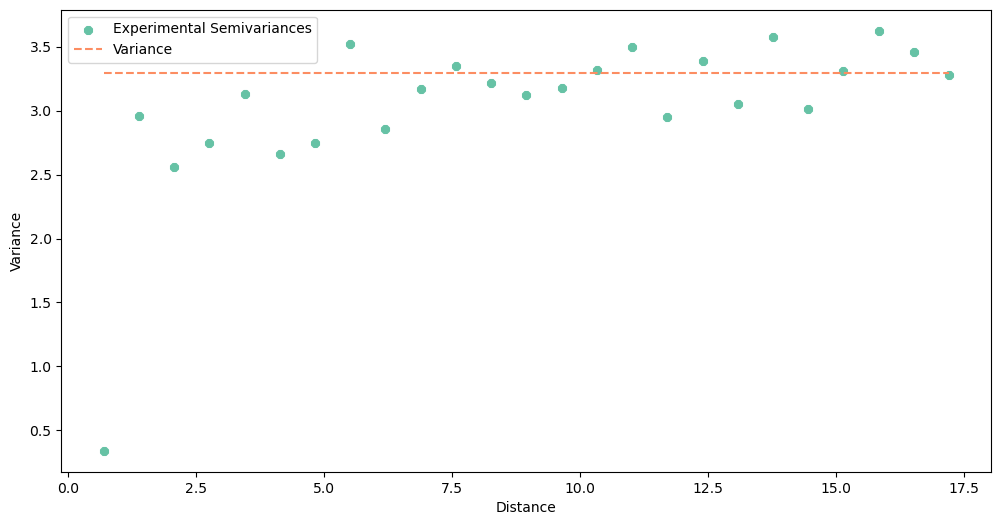

Building variogram for 210316...


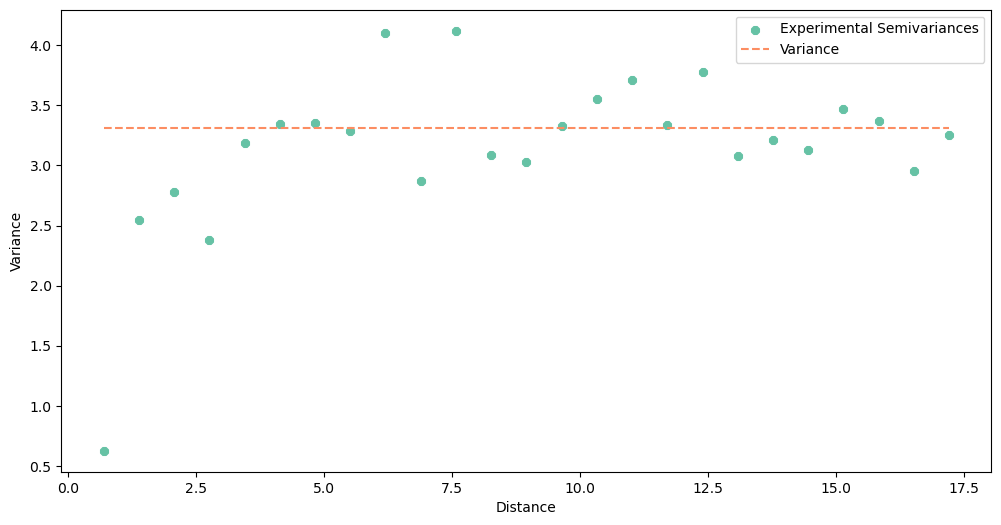

Building variogram for 210310...


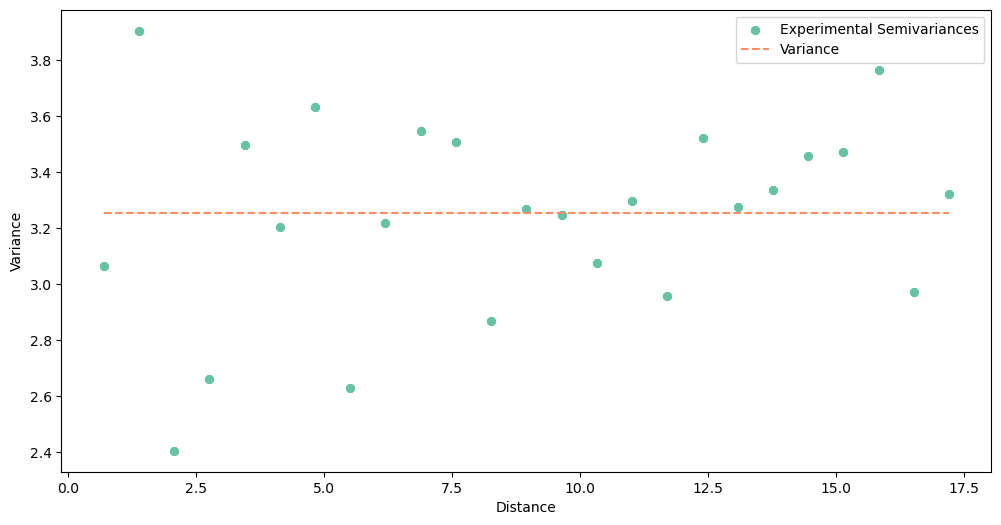

Building variogram for 210303...


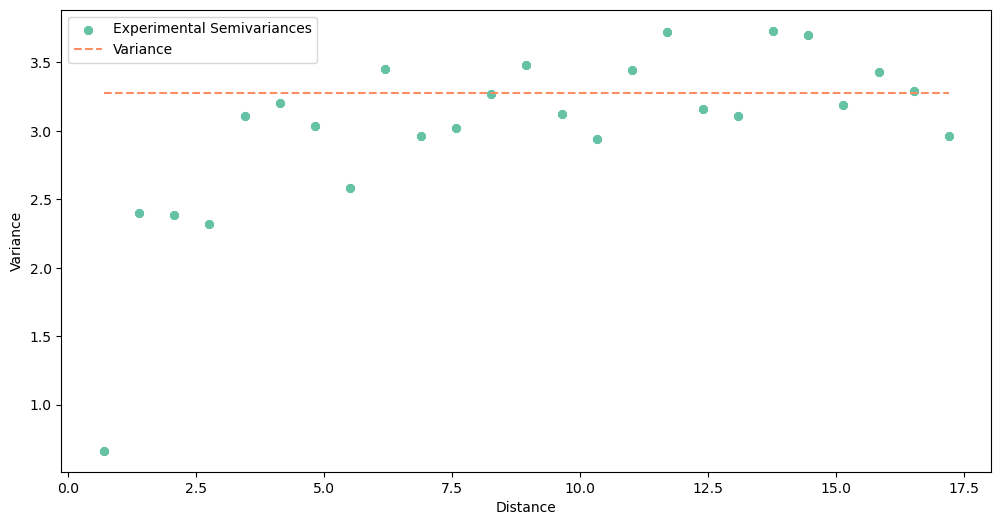

Building variogram for 210210...


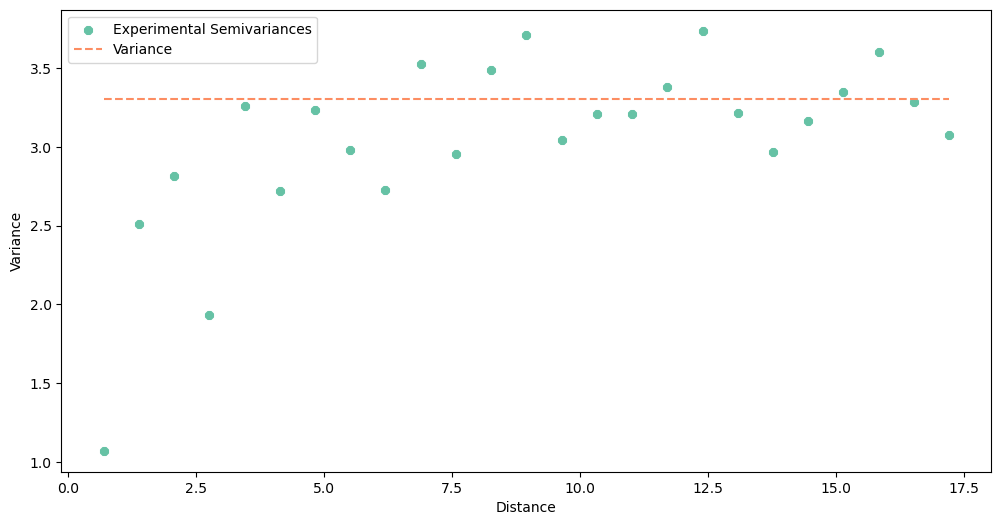

Building variogram for 210203...


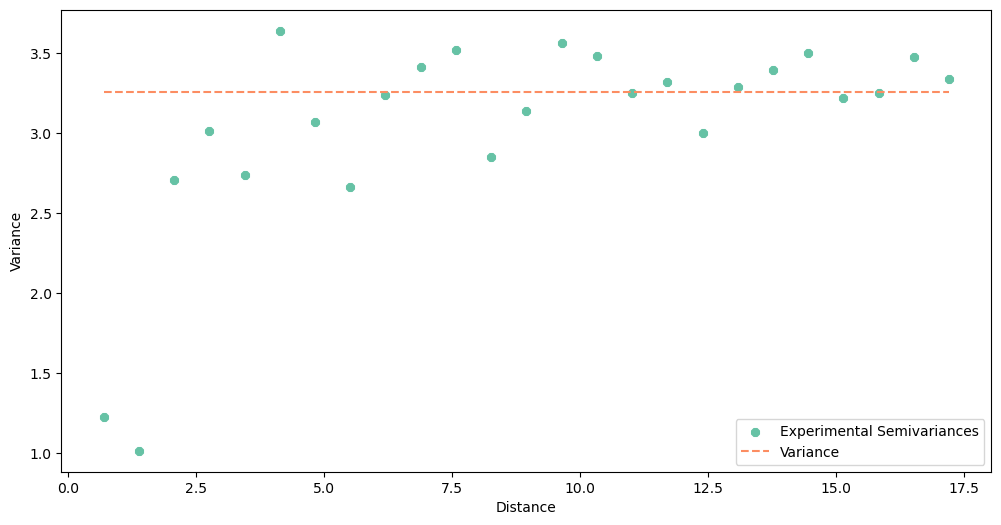

In [37]:
for d in data.coords['date'].values : 
    phase_slice = (
        data['phase'].sel(date=d)
        .where(files_xr.sel(date=1) > 0.6) # filter for areas of high crosspol coherence 
    )

    # get pixel size 
    # pixel_size = abs(phase_slice.rio.transform()[0])
    # print(f"Detected pixel resolution: {pixel_size} meters")

    # create a clean flat data frame 
    df = phase_slice.to_dataframe(name='value').reset_index()
    df = df.dropna(subset=['value'])
    df = df[df['value'] != -9999]  # Replace -9999 with your actual fill value if different

    # filter out areas of low coherence 
    # ? 

    # sample to allow calculation within a reasonable time frame 
    df_sample = df.sample(n=10000, random_state=42)

    geometries = df_sample[['x', 'y']].values  # Shape: (3000, 2)
    values = df_sample['value'].values        # Shape: (3000,)

    step_size = pixel_size       # Distance width of each bin (1 pixel wide)
    max_range = pixel_size * 25  # Max search distance (50 pixels away)

    # 8. Run the variogram
    print(f'Building variogram for {d}...')
    vario = build_experimental_variogram(
        values=values, 
        geometries=geometries, 
        step_size=step_size, 
        max_range=max_range
    )   
    
    vario.plot(covariance=False)
    plt.show()